# Creating `complex_clean.csv`

This notebook creates a cleaned version of `complex.csv` for controlled train/test benchmarking.

The original `complex.csv` dataset already contains an artificial anomaly in the `s1` signal. This is useful for visual analysis, but it can create problems for benchmark evaluation.

For the train/test benchmark, we want the base dataset to be clean or mostly normal before injecting synthetic anomalies into the test split. This is important because the evaluator only knows about the anomalies injected by the pipeline. If the original dataset already contains an unlabelled anomaly, a model might correctly detect it, but the evaluator would count it as a false positive.

So, in this notebook, we create `complex_clean.csv` by smoothing/removing the existing artificial anomaly in `s1`.

This is only a controlled dataset preparation step for the synthetic benchmark. It is not meant to be the final real-world cleaning strategy.

In the future, for real IoT datasets, the pipeline should include a more robust method to identify clean or mostly-normal training sections. For example, a baseline screening step could use simple detectors or data profiling to find the lowest-anomaly time windows and use those as assumed-normal training data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# Paths
DATA_DIR = Path("../datasets")  # adjust if your notebook is not inside data_science/development
input_path = DATA_DIR / "complex.csv"
output_path = DATA_DIR / "complex_clean.csv"

# Load dataset
df = pd.read_csv(input_path)
df.columns = df.columns.str.strip()

df_clean = df.copy()
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1008, 4)
   time        s1       s2        s3
0     0  1.000000  2.00000  0.700000
1     1  1.010000  1.99995  0.707000
2     2  1.019999  1.99980  0.713999
3     3  1.029996  1.99955  0.720997
4     4  1.039989  1.99920  0.727993


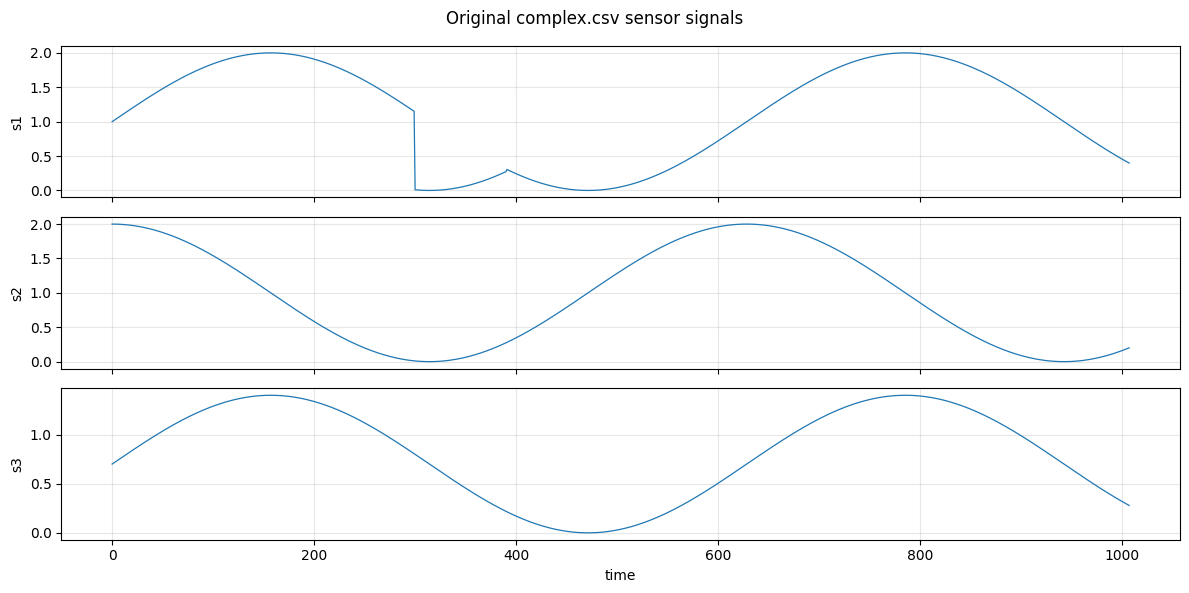

In [5]:
sensor_cols = ["s1", "s2", "s3"]

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

for ax, col in zip(axes, sensor_cols):
    ax.plot(df.index, df[col], linewidth=0.9)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("time")
plt.suptitle("Original complex.csv sensor signals")
plt.tight_layout()
plt.show()

In [7]:
df_clean = df.copy()

# Approximate anomalous region in s1
start_idx = 300
end_idx = 395

# Set the anomalous region to missing
df_clean.loc[start_idx:end_idx, "s1"] = None

# Interpolate the missing region using surrounding clean values
df_clean["s1"] = df_clean["s1"].interpolate(method="linear")

print(f"Cleaned s1 from index {start_idx} to {end_idx} using interpolation")

Cleaned s1 from index 300 to 395 using interpolation


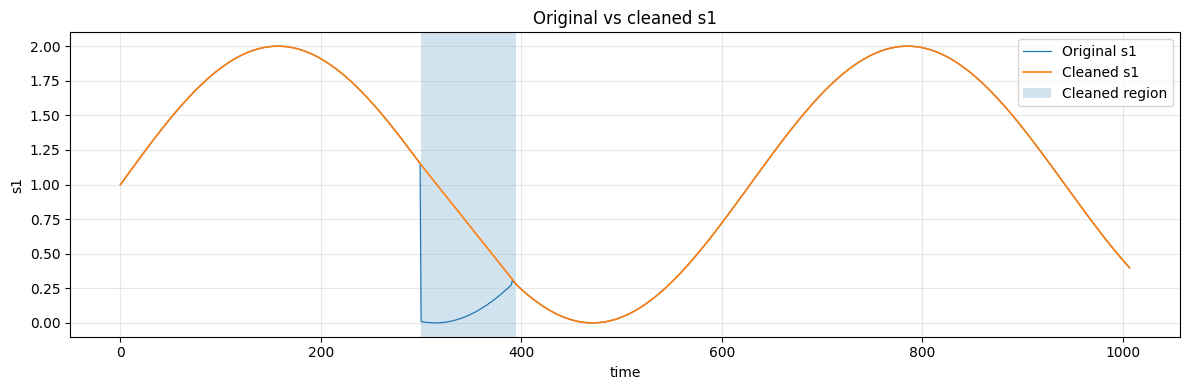

In [8]:
plt.figure(figsize=(12, 4))

plt.plot(df.index, df["s1"], label="Original s1", linewidth=0.9)
plt.plot(df_clean.index, df_clean["s1"], label="Cleaned s1", linewidth=1.2)

plt.axvspan(start_idx, end_idx, alpha=0.2, label="Cleaned region")

plt.title("Original vs cleaned s1")
plt.xlabel("time")
plt.ylabel("s1")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

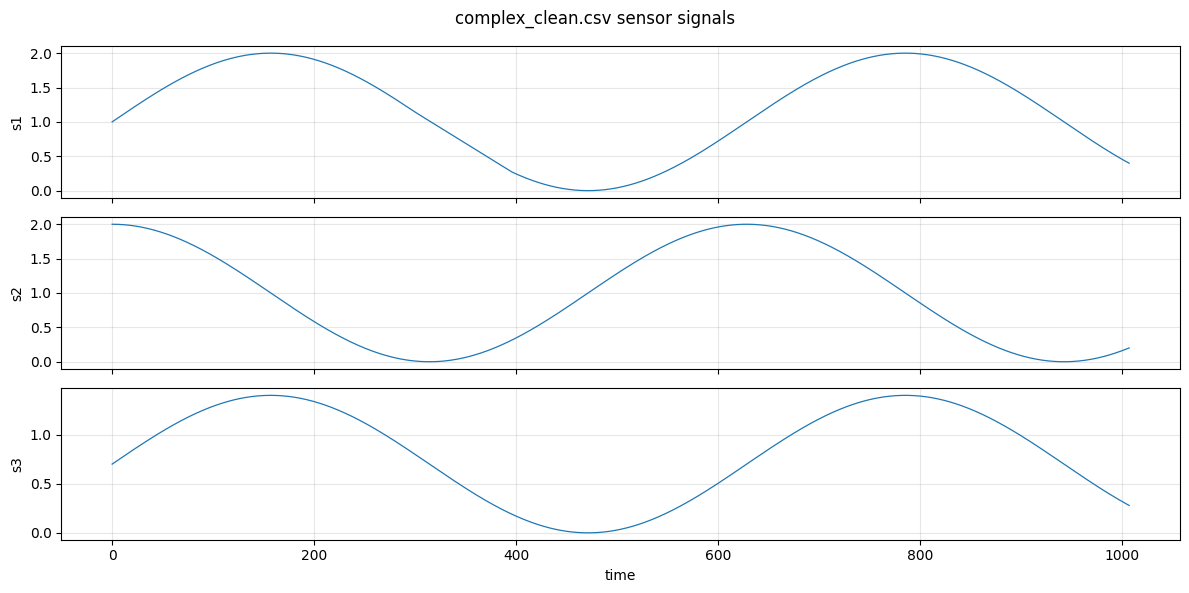

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

for ax, col in zip(axes, sensor_cols):
    ax.plot(df_clean.index, df_clean[col], linewidth=0.9)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("time")
plt.suptitle("complex_clean.csv sensor signals")
plt.tight_layout()
plt.show()

In [10]:
df_clean.to_csv(output_path, index=False)

print(f"Saved cleaned dataset to: {output_path}")
print("Cleaned dataset shape:", df_clean.shape)

Saved cleaned dataset to: ..\datasets\complex_clean.csv
Cleaned dataset shape: (1008, 4)


In [11]:
df_check = pd.read_csv(output_path)

print("Reloaded cleaned dataset shape:", df_check.shape)
print(df_check.head())

Reloaded cleaned dataset shape: (1008, 4)
   time        s1       s2        s3
0     0  1.000000  2.00000  0.700000
1     1  1.010000  1.99995  0.707000
2     2  1.019999  1.99980  0.713999
3     3  1.029996  1.99955  0.720997
4     4  1.039989  1.99920  0.727993


## Final note

The cleaned file `complex_clean.csv` is now available as a controlled clean baseline for train/test benchmarking.

The intended benchmark flow is:

clean base dataset  
=> time-based train/test split  
=> fit trainable models on the clean training split  
=> inject synthetic anomalies only into the test split  
=> evaluate predictions against known injected labels  

This makes the evaluation fairer because the only anomalies in the test labels are the ones intentionally injected by the benchmark pipeline.

For future real IoT datasets, this manual cleaning approach should be replaced with a more general clean-window selection process. That future process could analyse the dataset first, identify obvious anomalous regions, rank time windows by anomaly density, and use the cleanest windows as assumed-normal training data.